In [3]:
import sys
from pathlib import Path

# racine du projet = un niveau au dessus de notebooks/
root = Path().resolve().parent
sys.path.append(str(root))

from src.data.download import estimate_cost

In [4]:
from loader import load_raw_data

file_path = "../data/raw/FGBL.v.0_2025-11-03.parquet"

df = load_raw_data(file_path)
df.head(100)

,ts_event,rtype,publisher_id,instrument_id,action,side,price,size,channel_id,order_id,flags,ts_in_delta,sequence,symbol
ts_recv,,,,,,,,,,,,,,
2025-11-03 00:15:01.080410243+00:00,2025-11-03 00:15:01.080010385+00:00,160,101,19,R,N,NaN,0,3,0,8,0,0,FGBL.v.0
2025-11-03 00:15:01.080410243+00:00,2025-11-03 00:15:01.080010385+00:00,160,101,19,T,N,129.41,35,3,0,0,4197,772,FGBL.v.0
2025-11-03 00:15:01.080410243+00:00,2025-11-03 00:00:00+00:00,160,101,19,A,B,129.41,91,3,10985308069428080303,0,4197,772,FGBL.v.0
2025-11-03 00:15:01.080410243+00:00,2025-11-03 00:00:00+00:00,160,101,19,A,A,129.42,1,3,1762128004853108363,0,4197,772,FGBL.v.0
2025-11-03 00:15:01.080410243+00:00,2025-11-03 00:00:00+00:00,160,101,19,A,B,129.40,22,3,10985304862704247388,0,4197,772,FGBL.v.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-03 00:15:01.080434173+00:00,2025-11-03 00:00:00+00:00,160,101,19,A,A,129.51,56,3,1761914509125738873,0,3979,776,FGBL.v.0
2025-11-03 00:15:01.080434173+00:00,2025-11-03 00:00:00+00:00,160,101,19,A,A,129.51,50,3,1761944333604746905,0,3979,776,FGBL.v.0
2025-11-03 00:15:01.080434173+00:00,2025-11-03 00:00:00+00:00,160,101,19,A,A,129.51,4,3,1762128070034561953,0,3979,776,FGBL.v.0


In [5]:
len(df)

2384150

In [6]:
import sys
sys.path.insert(0, '/Users/ulysse/Desktop/Studies/Imperial/Market Microstructure/queue-modelling-LBO')
import pandas as pd
from src.data.preprocess import clean_mbo

df_raw = pd.read_parquet('/Users/ulysse/Desktop/Studies/Imperial/Market Microstructure/queue-modelling-LBO/data/raw/FGBL.v.0_2025-11-03.parquet')
print('Raw rows:', len(df_raw))

df = clean_mbo(df_raw)
print('Clean rows:', len(df))
print()
print('=== Schema ===')
print(df.dtypes)
print()
print('=== Index ===')
print('name:', df.index.name, '| dtype:', df.index.dtype)
print('range:', df.index.min(), '->', df.index.max())
print()
print('=== action counts after clean ===')
print(df['action'].value_counts())
print()
print('=== side counts after clean ===')
print(df['side'].value_counts())
print()
print('=== sample ===')
print(df[['action','side','price','size','order_id']].head(8).to_string())



Raw rows: 2384150
Clean rows: 1932297

=== Schema ===
action     object
side       object
price     float64
size       uint32
dtype: object

=== Index ===
name: ts | dtype: datetime64[ns, Europe/Berlin]
range: 2025-11-03 09:00:00.000171535+01:00 -> 2025-11-03 17:59:59.048966651+01:00

=== action counts after clean ===
action
C    937240
A    911405
T     83652
Name: count, dtype: int64

=== side counts after clean ===
side
B    989339
A    942958
Name: count, dtype: int64

=== sample ===


KeyError: "['order_id'] not in index"

In [ ]:
df_all = pd.read_parquet("../data/processed/FGBL_clean.parquet")
df_all.head()

,action,side,price,size,date
ts,,,,,
2025-11-03 09:00:00.000171535+01:00,C,B,129.27,8,2025-11-03
2025-11-03 09:00:00.000246115+01:00,A,B,129.27,5,2025-11-03
2025-11-03 09:00:00.000255689+01:00,A,B,129.30,12,2025-11-03
2025-11-03 09:00:00.000289399+01:00,A,A,129.33,12,2025-11-03
2025-11-03 09:00:00.000289949+01:00,C,A,129.34,8,2025-11-03


In [ ]:
df_lbo = pd.read_parquet("../data/processed/FGBL_event_flow.parquet")
df_lbo.head()

,date,side,level,eta,q_before,size,delta_t,p_ref,p_mid
ts,,,,,,,,,
2025-11-03 09:00:00.001305390+01:00,2025-11-03,A,1,L,923,10,0.000000,129.375,129.375
2025-11-03 09:00:00.008229226+01:00,2025-11-03,A,1,C,933,10,0.006923,129.375,129.375
2025-11-03 09:00:00.014896417+01:00,2025-11-03,A,1,L,923,10,0.006667,129.375,129.375
2025-11-03 09:00:00.037645717+01:00,2025-11-03,A,1,C,933,10,0.022749,129.375,129.375
2025-11-03 09:00:00.059586329+01:00,2025-11-03,A,1,C,923,3,0.021940,129.375,129.375


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date

# Load event flow for 2025-11-17
df_flow = pd.read_parquet("../data/processed/FGBL_event_flow.parquet")
df_day = df_flow[df_flow["date"] == date(2025, 11, 17)].copy()

print(f"Events on 2025-11-17: {len(df_day):,}")
print(f"p_ref range: {df_day['p_ref'].min():.3f} – {df_day['p_ref'].max():.3f}")
df_day.head()

Events on 2025-11-17: 255,366
p_ref range: 128.560 – 128.645


,date,side,level,eta,q_before,size,delta_t,p_ref,p_mid
ts,,,,,,,,,
2025-11-17 09:00:00.000267518+01:00,2025-11-17,A,5,L,1449,12,0.000000,128.56,128.56
2025-11-17 09:00:00.000436739+01:00,2025-11-17,A,5,M,1461,1,0.000169,128.56,128.56
2025-11-17 09:00:00.000436739+01:00,2025-11-17,A,5,C,1460,1,0.000000,128.56,128.56
2025-11-17 09:00:00.000503851+01:00,2025-11-17,A,5,L,1459,4,0.000067,128.56,128.56
2025-11-17 09:00:00.000597512+01:00,2025-11-17,B,1,C,1381,8,0.000000,128.56,128.56


In [ ]:
TICK = 0.01

def get_lob_snapshot(df_day: pd.DataFrame, time_str: str) -> pd.DataFrame:
    """
    Reconstruct queue sizes at each (side, level) just before a given intraday time.
    Uses q_before of the last event per (side, level) within the current p_ref period.
    Returns DataFrame: side, level, price, queue, p_ref.
    """
    t = pd.Timestamp(f"2025-11-17 {time_str}", tz="Europe/Berlin")
    df_before = df_day[df_day.index <= t]
    if df_before.empty:
        return pd.DataFrame()

    last_p_ref = df_before["p_ref"].iloc[-1]
    p_ref_int_x2 = round(last_p_ref * 2 / TICK)

    # Within current p_ref period, compute q_after = q_before ± size for each event
    df_cur = df_before[df_before["p_ref"] == last_p_ref].copy()
    df_cur["q_after"] = df_cur.apply(
        lambda r: max(0, r["q_before"] + r["size"] if r["eta"] == "L" else r["q_before"] - r["size"]),
        axis=1,
    )

    # Last q_after per (side, level)
    snap = df_cur.groupby(["side", "level"])["q_after"].last().reset_index()
    snap.rename(columns={"q_after": "queue"}, inplace=True)
    snap["p_ref"] = last_p_ref

    # Absolute price for each level (1-tick spread assumed: p_ref_int_x2 is odd)
    def level_to_price(row):
        k = int(row["level"])
        if row["side"] == "B":
            price_int = (p_ref_int_x2 - (2 * k - 1)) / 2
        else:
            price_int = (p_ref_int_x2 + (2 * k - 1)) / 2
        return round(price_int * TICK, 4)

    snap["price"] = snap.apply(level_to_price, axis=1)
    return snap.sort_values(["side", "level"])

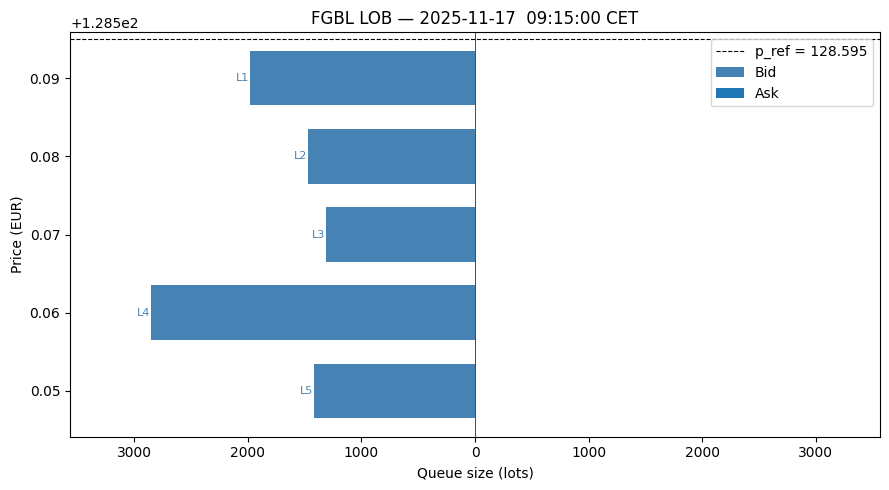

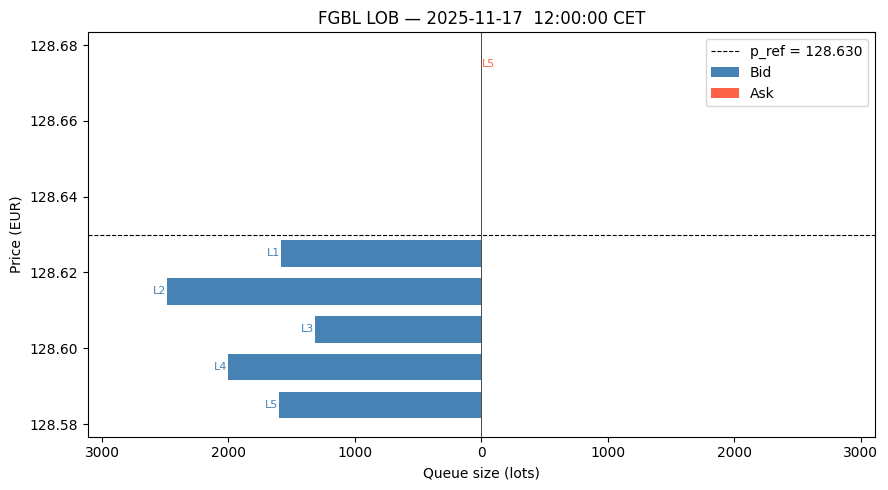

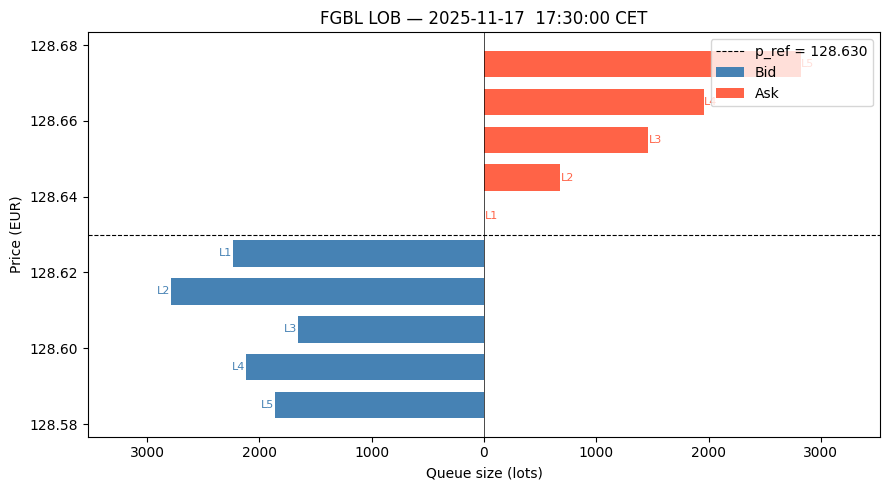

In [ ]:
def plot_lob_depth(snap: pd.DataFrame, time_str: str):
    """Static depth chart: bid levels (blue) left, ask levels (red) right, price on y-axis."""
    bids = snap[snap["side"] == "B"].sort_values("level")
    asks = snap[snap["side"] == "A"].sort_values("level")
    p_ref = snap["p_ref"].iloc[0]

    fig, ax = plt.subplots(figsize=(9, 5))

    # Bid bars (negative = left side)
    ax.barh(bids["price"], -bids["queue"], height=0.007, color="steelblue",
            align="center", label="Bid")
    # Ask bars (positive = right side)
    ax.barh(asks["price"], asks["queue"], height=0.007, color="tomato",
            align="center", label="Ask")

    ax.axhline(p_ref, color="black", linestyle="--", linewidth=0.8,
               label=f"p_ref = {p_ref:.3f}")
    ax.axvline(0, color="black", linewidth=0.5)

    # Label levels
    for _, r in bids.iterrows():
        ax.text(-r["queue"] - 5, r["price"], f"L{int(r['level'])}", va="center",
                ha="right", fontsize=8, color="steelblue")
    for _, r in asks.iterrows():
        ax.text(r["queue"] + 5, r["price"], f"L{int(r['level'])}", va="center",
                ha="left", fontsize=8, color="tomato")

    max_q = max(snap["queue"].max(), 1)
    ax.set_xlim(-max_q * 1.25, max_q * 1.25)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{abs(int(x))}"))
    ax.set_xlabel("Queue size (lots)")
    ax.set_ylabel("Price (EUR)")
    ax.set_title(f"FGBL LOB — 2025-11-17  {time_str} CET")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

# Show snapshots at three times: open, noon, close
for t in ["09:15:00", "12:00:00", "17:30:00"]:
    snap = get_lob_snapshot(df_day, t)
    if not snap.empty:
        plot_lob_depth(snap, t)
    else:
        print(f"No data before {t}")

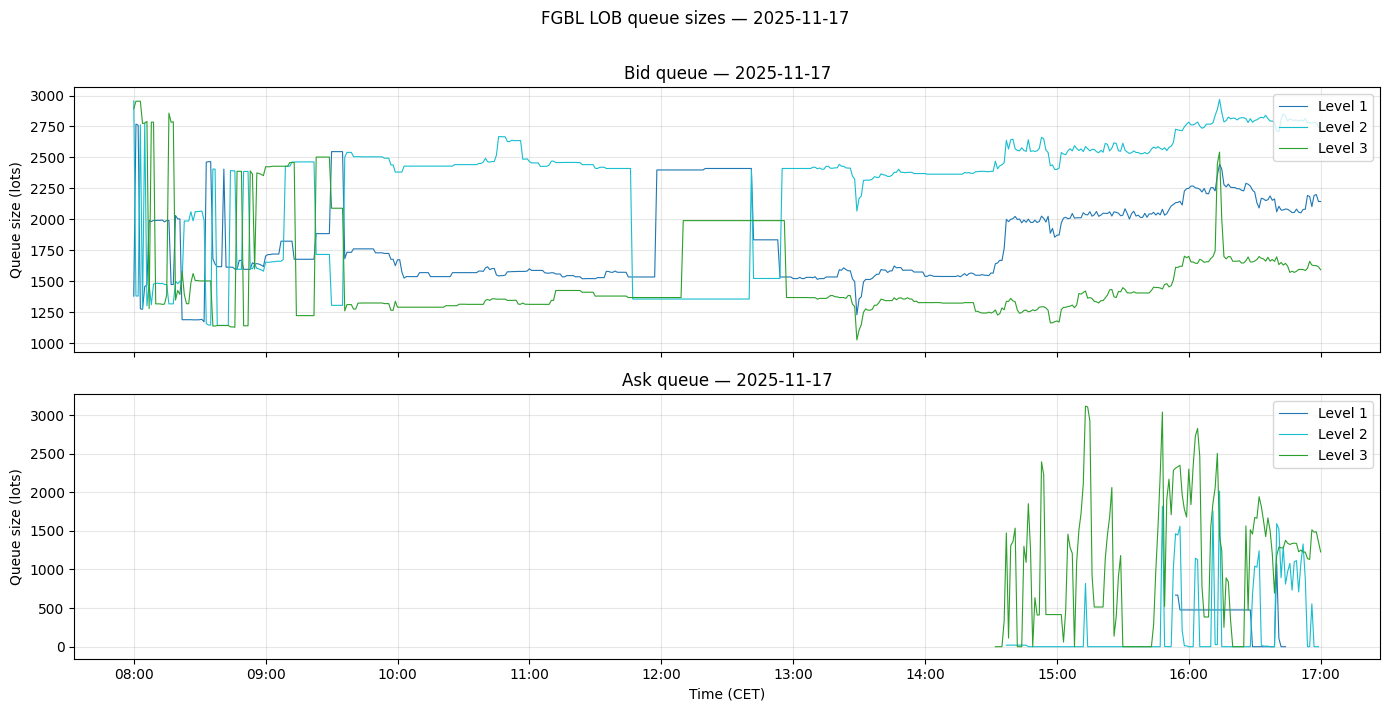

In [ ]:
import matplotlib.dates as mdates

# Compute q_after for every event on 2025-11-17
df_plot = df_day.copy()
df_plot["q_after"] = df_plot.apply(
    lambda r: max(0, r["q_before"] + r["size"] if r["eta"] == "L" else r["q_before"] - r["size"]),
    axis=1,
)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

colors = {1: "tab:blue", 2: "tab:cyan", 3: "tab:green"}

for ax, side, label in zip(axes, ["B", "A"], ["Bid", "Ask"]):
    df_side = df_plot[df_plot["side"] == side]
    for lvl in [1, 2, 3]:
        df_lvl = df_side[df_side["level"] == lvl][["q_after"]].copy()
        # Resample to 1-minute intervals, taking the last observed q_after
        df_lvl_1m = df_lvl.resample("1min").last().ffill()
        ax.plot(df_lvl_1m.index, df_lvl_1m["q_after"],
                linewidth=0.8, color=colors[lvl], label=f"Level {lvl}")
    ax.set_ylabel("Queue size (lots)")
    ax.set_title(f"{label} queue — 2025-11-17")
    ax.legend(loc="upper right")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_major_locator(mdates.HourLocator())
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (CET)")
plt.suptitle("FGBL LOB queue sizes — 2025-11-17", y=1.01)
plt.tight_layout()
plt.show()

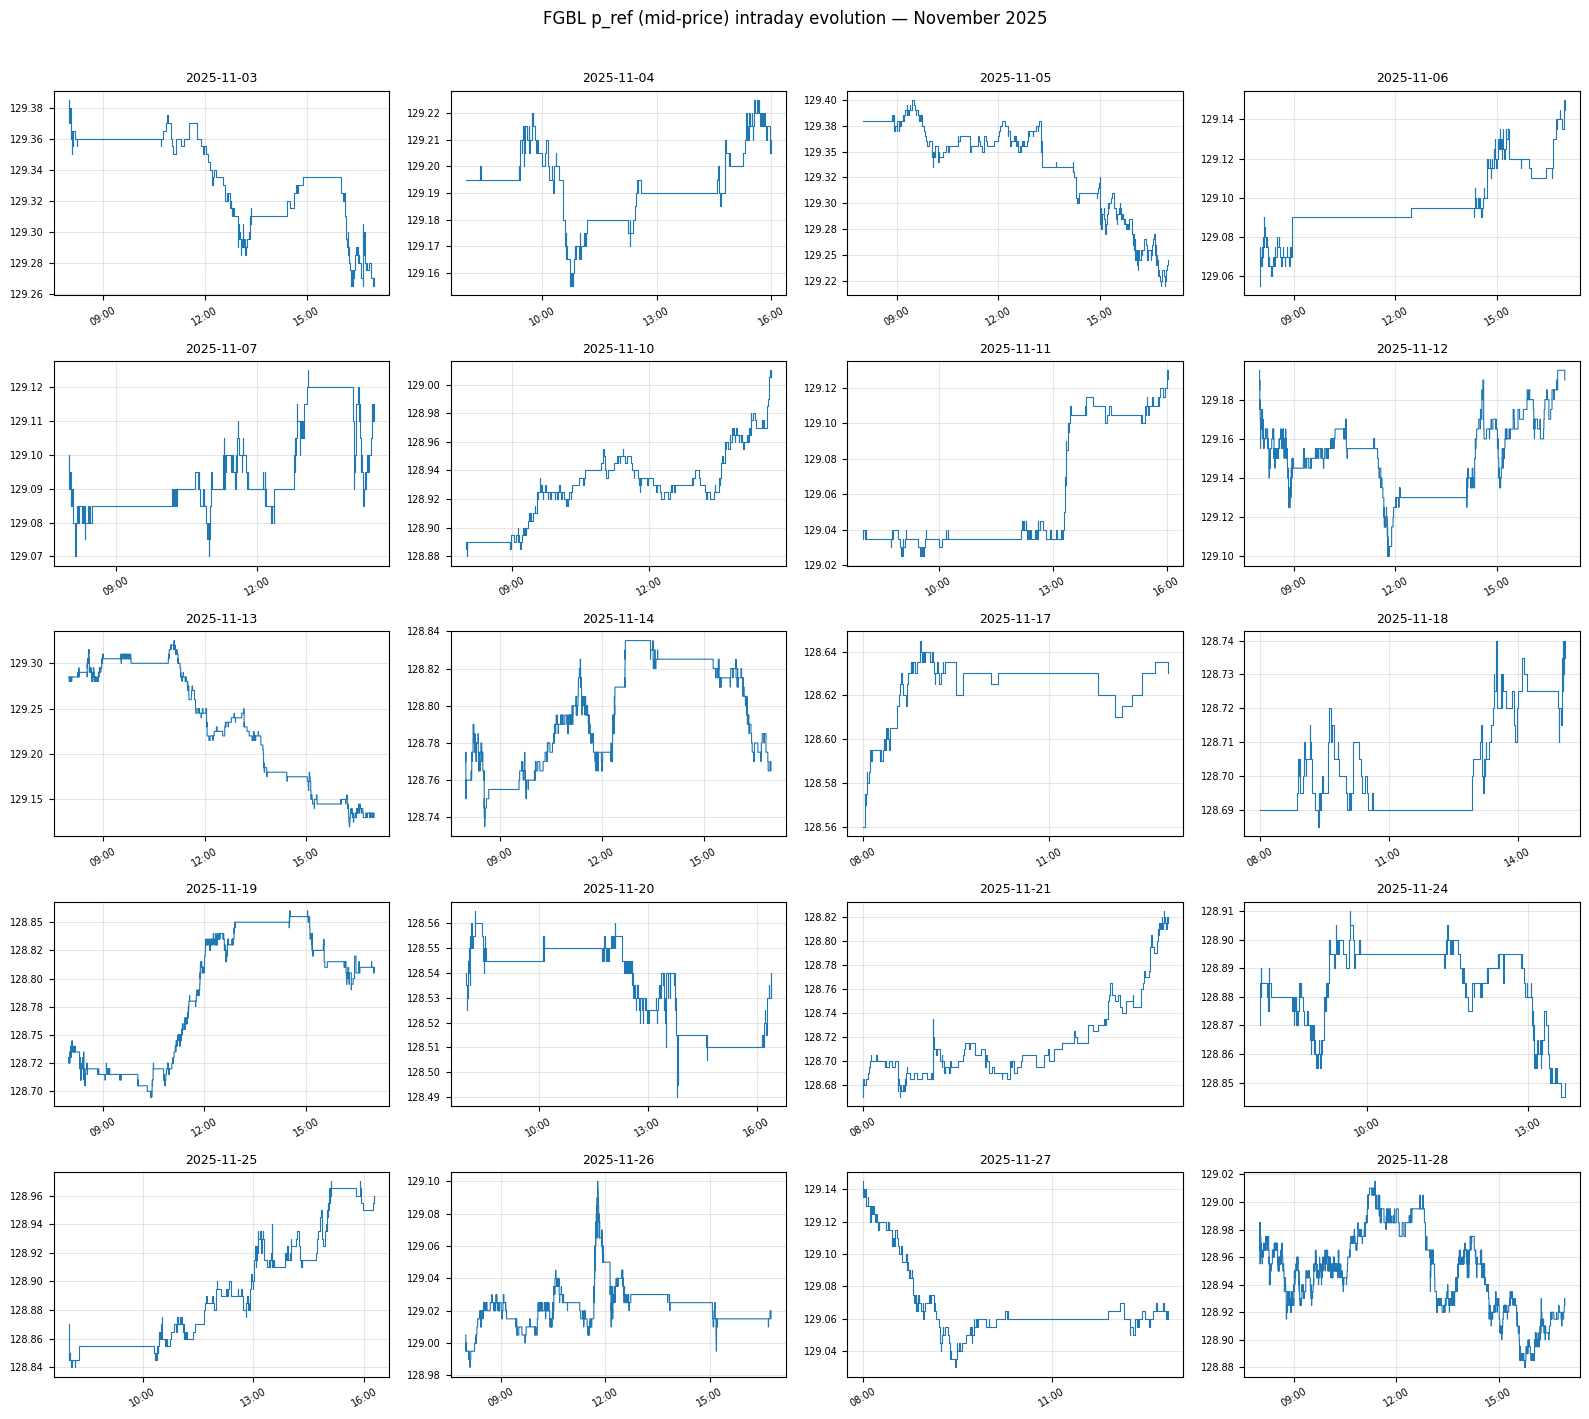

In [ ]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

# p_ref changes only when the mid-price moves — keep one row per change
df_pref = df_flow[["p_ref"]].copy()
df_pref = df_pref[df_pref["p_ref"] != df_pref["p_ref"].shift()]  # keep transitions only

trading_days = sorted(df_flow["date"].unique())
ncols = 4
nrows = -(-len(trading_days) // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 2.8), sharey=False)
axes = axes.flatten()

for i, day in enumerate(trading_days):
    ax = axes[i]
    mask = df_pref.index.date == day
    df_d = df_pref[mask]

    ax.step(df_d.index, df_d["p_ref"], where="post", linewidth=0.8, color="tab:blue")
    ax.set_title(str(day), fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
    ax.tick_params(axis="x", labelsize=7, rotation=30)
    ax.tick_params(axis="y", labelsize=7)
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter("%.2f"))
    ax.grid(alpha=0.3)

# Hide unused subplots
for j in range(len(trading_days), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("FGBL p_ref (mid-price) intraday evolution — November 2025", y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
df = pd.read_parquet("../data/processed/FGBL_qr_features.parquet")
n_changes = (df["p_ref"] != df["p_ref"].shift()).sum()
print(f"p_ref changes: {n_changes}")  # should be in the thousands for a full month

p_ref changes: 1393


In [ ]:
# How many full consumptions do you detect?
consumed = df[(df["level"] == 1) & (df["q_before"] <= df["size"])]
print(f"Full consumptions detected: {len(consumed)}")
# For a full month of Bund, you'd expect thousands of these

Full consumptions detected: 27143


In [8]:
df.head()

,date,side,level,eta,q_before,size,delta_t,p_ref,p_mid,q_before_aes,period_id
ts,,,,,,,,,,,
2025-11-03 09:00:00.000308396+01:00,2025-11-03,A,2,L,0,12,0.0,129.315,129.315,0,0
2025-11-03 09:00:00.000311813+01:00,2025-11-03,A,3,C,0,8,0.0,129.315,129.315,0,0
2025-11-03 09:00:00.000318825+01:00,2025-11-03,A,4,C,0,7,0.0,129.315,129.315,0,0
2025-11-03 09:00:00.000338062+01:00,2025-11-03,A,2,C,12,5,0.0,129.315,129.315,2,0
2025-11-03 09:00:00.000363098+01:00,2025-11-03,B,3,C,0,6,0.0,129.315,129.315,0,0
